# Hotdog or Not Hotdog App

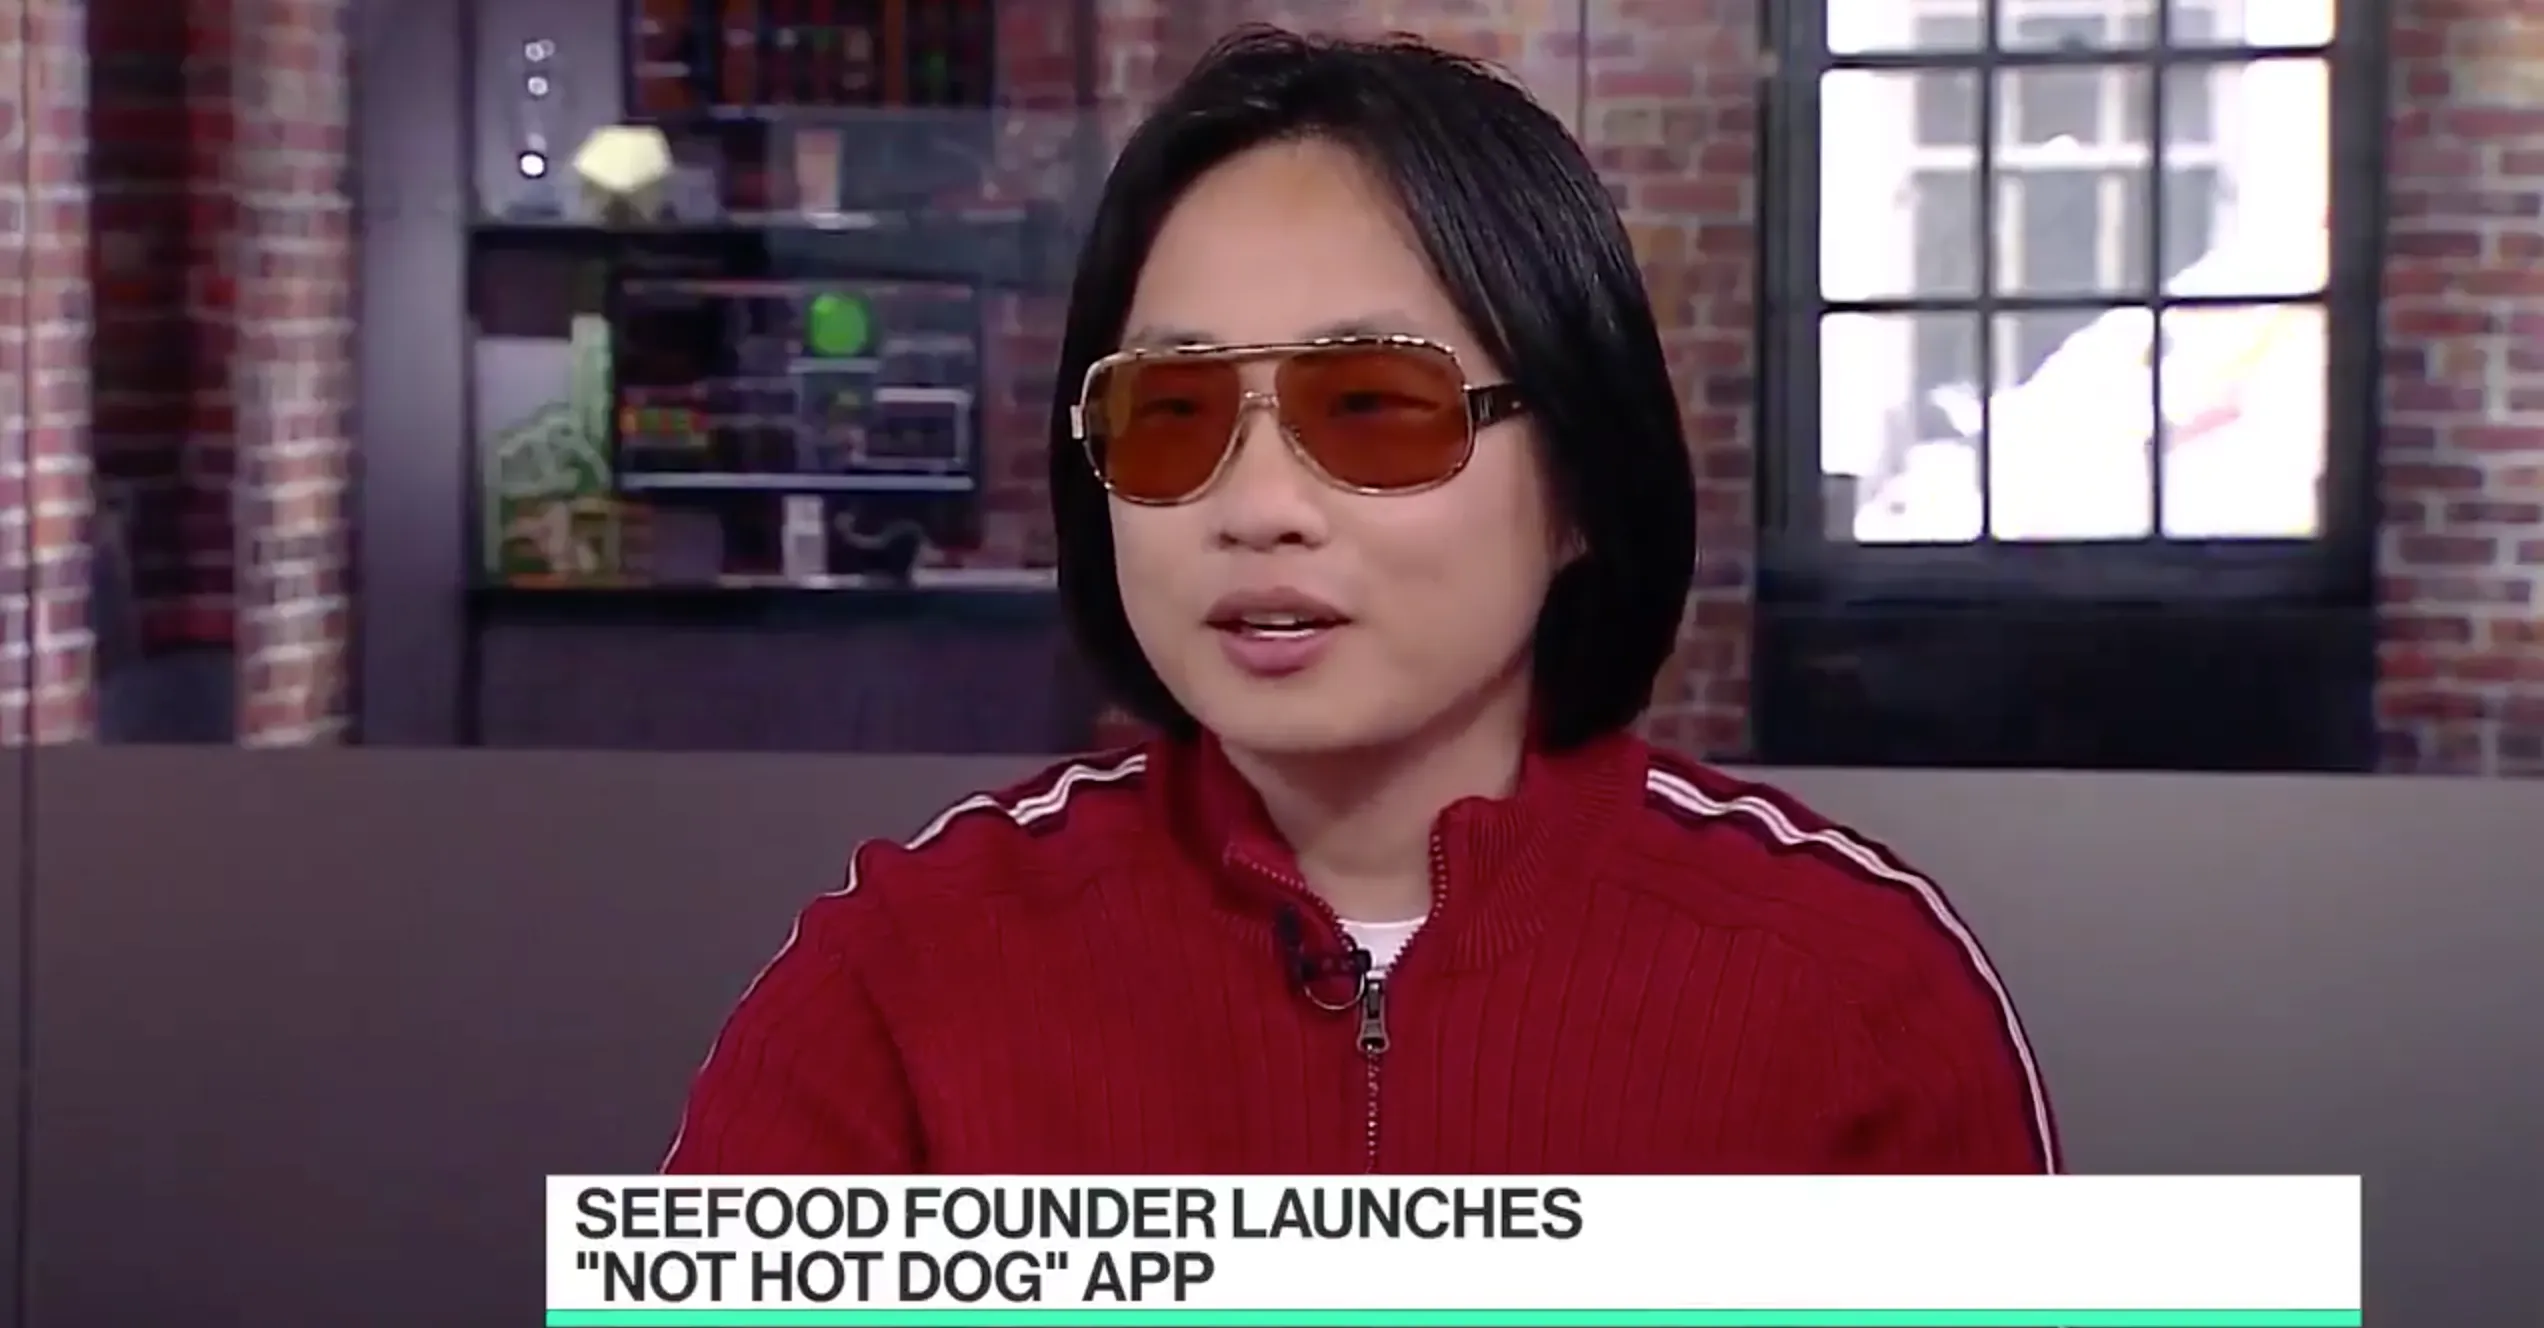

In the first lecture for CS231N, Fei-Fei Li mentioned the rapid advancement of deep learning and computer vision. She said "You could train Jian Yang's hotdog app in 10 minutes." So I thought I would just do this real quick to appreciate how intuitive image classification with deep learning can be.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yashvrdnjain/hotdognothotdog")

print("Path to dataset files:", path)

100%|██████████| 166M/166M [00:01<00:00, 113MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/yashvrdnjain/hotdognothotdog/versions/1


## Data

It was a little tedious finding a good dataset. The following has 3000 training images (hopefully enough), containing 1500 hot dog images. The test set is 322 images. To allow the model to generalize better, I augment with `transforms.RandomHorizontalFlip()` and `transforms.RandomRotation(15)`. This does not create more data, but creates small rotations (and flips) to allow it to generalize.

In [ ]:
import os

path = os.path.join(path, 'hotdog-nothotdog')

print(os.listdir(path))

['test', 'train']


`transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]) `rescales pixel values so they're centered around 0 and spread roughly between -1 and 1. In general, it can be a good idea to normalize data to have zero mean and unit variance, which helps stabilize and accelerate the training of neural networks.

Classes: ['hotdog', 'nothotdog']
Num images: 3000


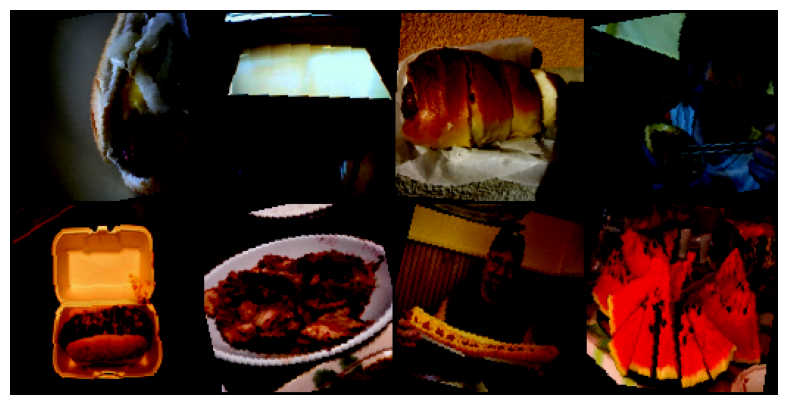

In [ ]:
import os
import matplotlib.pyplot as plt
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Use the path from kagglehub.dataset_download, which is available globally.
# The 'path' variable is already set from the previous cell.

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(), # Data augmentation
    transforms.RandomRotation(15),    # Data augmentation
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

train_dataset = datasets.ImageFolder(
    root=os.path.join(path, 'train'),
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

print('Classes:', train_dataset.classes)
print('Num images:', len(train_dataset))

images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 5))
grid = torchvision.utils.make_grid(images[:8], nrow=4)
plt.imshow(grid.permute(1, 2, 0))
plt.axis('off')
plt.show()

## The model

The model is a convolutional neural network for binary image classification. It takes in a 3-channel RGB image and applies three convolutional blocks. Each block consists of a convolution, BatchNorm, ReLU, and MaxPool. These layers progressively extract more complex visual features while reducing the spatial size of the representation.

The channel dimensions increase from 3 -> 32 -> 64 -> 128, which allows the model to capture richer features at deeper layers. After the final convolutional block, the feature map is flattened and passed through a fully connected layer with ReLU and dropout. The dropout layer is used to reduce overfitting. The final linear layer produces 2 output scores, one for each class: hot dog and not hot dog.

__Why batchnorm?__
1. Faster training: You can use larger learning rates.

2. More stable gradients: Reduces exploding / vanishing gradients.

3. Regularization effect: Often reduces overfitting slightly.

4. Less sensitivity to initialization: Training becomes more predictable.

In [ ]:
import torch
import torch.nn as nn

class FoodModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), # Added BatchNorm
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), # Added BatchNorm
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), # Added BatchNorm
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 128),
            nn.ReLU(),
            nn.Dropout(0.5), # Added Dropout
            nn.Linear(128, 2)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
import torch.optim as optim
import numpy as np

food_model = FoodModel()

# Reduced learning rate and removed weight decay for better learning
optimizer = optim.AdamW(food_model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

In [ ]:
def train(model, optimizer, criterion, train_data, epochs = 10):
  loss_history = []
  model.train()
  for epoch in range(epochs):
    epoch_loss = []
    for x, y in train_data:
      optimizer.zero_grad()
      y_pred = model(x)
      loss = criterion(y_pred, y)

      loss_history += [loss.item()]
      epoch_loss += [loss.item()]

      loss.backward()
      optimizer.step()

    print(f"Epoch {epoch} loss: {np.mean(epoch_loss)}")

  return loss_history

In [ ]:
loss_history = train(food_model, optimizer, criterion, train_loader, 100)

Epoch 0 loss: 1.118218924929487
Epoch 1 loss: 0.6346546161047956
Epoch 2 loss: 0.6226809497209306
Epoch 3 loss: 0.6044956670796617
Epoch 4 loss: 0.5997664062900746
Epoch 5 loss: 0.6099675342123559
Epoch 6 loss: 0.5954070535111935
Epoch 7 loss: 0.5924200802407367
Epoch 8 loss: 0.6032295523488775
Epoch 9 loss: 0.5887649999336994
Epoch 10 loss: 0.5942429594219999
Epoch 11 loss: 0.5775027576279133
Epoch 12 loss: 0.5867945131786326
Epoch 13 loss: 0.5788215019918502
Epoch 14 loss: 0.5702989466012792
Epoch 15 loss: 0.5725661915667514
Epoch 16 loss: 0.5495890661122951
Epoch 17 loss: 0.5554542869646498
Epoch 18 loss: 0.5435027148812375
Epoch 19 loss: 0.5481669213226501
Epoch 20 loss: 0.5547417560790447
Epoch 21 loss: 0.5498679107491006
Epoch 22 loss: 0.5355435766755267
Epoch 23 loss: 0.5344005572669049
Epoch 24 loss: 0.5203562274258188
Epoch 25 loss: 0.5319888483970723
Epoch 26 loss: 0.529968945269889
Epoch 27 loss: 0.5307494709466366
Epoch 28 loss: 0.5103465259233688
Epoch 29 loss: 0.521871938

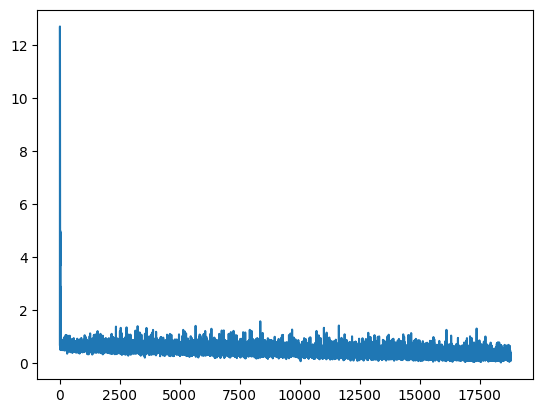

In [17]:
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.show()

In [ ]:
import torch
import numpy as np

def evaluate(model, criterion, data_loader):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in data_loader:

            y_pred = model(x)

            loss = criterion(y_pred, y)
            total_loss += loss.item()

            preds = torch.argmax(y_pred, dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    avg_loss = total_loss / len(data_loader)
    accuracy = correct / total

    print(f"Eval loss: {avg_loss:.4f}")
    print(f"Accuracy: {accuracy:.4f}")

    return avg_loss, accuracy

In [ ]:
test_dataset = datasets.ImageFolder(
    root=os.path.join(path, 'test'),
    transform=transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=True
)

In [16]:
evaluate(food_model, criterion, test_loader)

Eval loss: 0.7620
Accuracy: 0.7640


(0.7620316931023831, 0.7639751552795031)

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision

# Get a batch of test images and labels
images, labels = next(iter(test_loader))

# Make predictions
food_model.eval()
with torch.no_grad():
    outputs = food_model(images)
    _, predicted = torch.max(outputs, 1)

# Get class names
class_names = test_dataset.classes

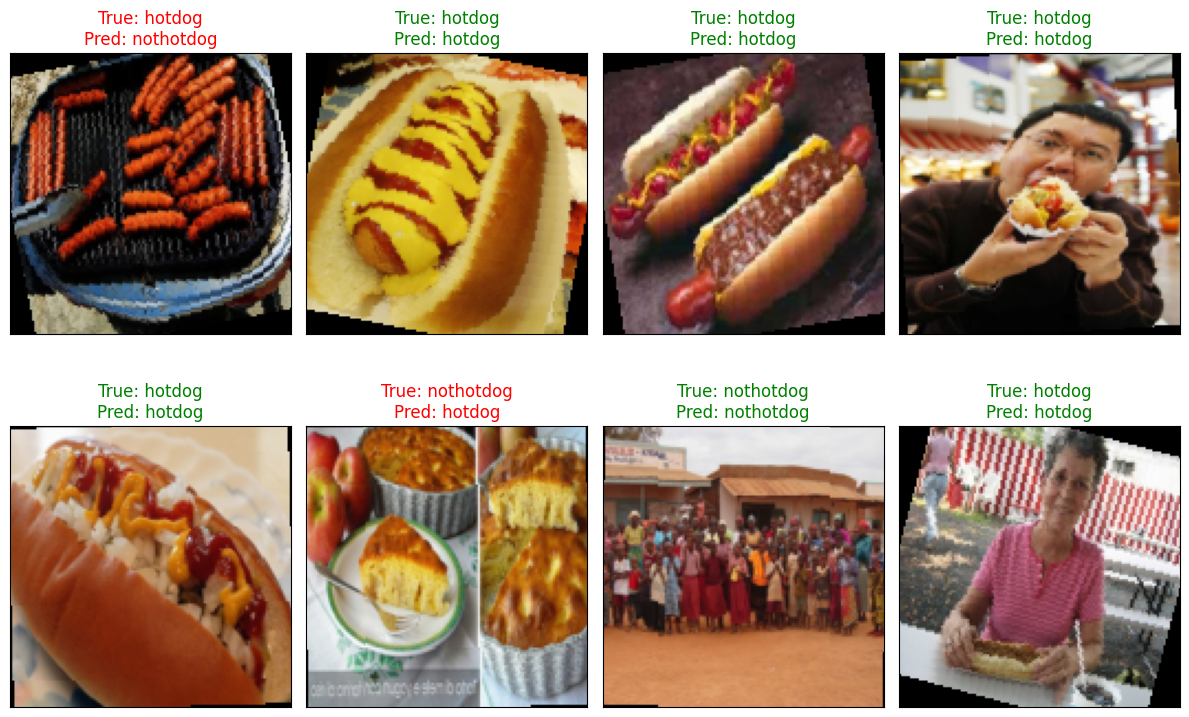

In [19]:
# Function to unnormalize images for display
def unnormalize(img):
    img = img * 0.5 + 0.5  # Unnormalize
    return img

# Plotting function
fig = plt.figure(figsize=(12, 8))
for i in range(8): # Display first 8 images in the batch
    ax = fig.add_subplot(2, 4, i + 1, xticks=[], yticks=[])
    img = unnormalize(images[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    color = "green" if predicted[i] == labels[i] else "red"
    ax.set_title(f"True: {class_names[labels[i]]}\nPred: {class_names[predicted[i]]}", color=color)
plt.tight_layout()
plt.show()

__This prediction can still be better, but a good first prototype!__